In [4]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

# Load dataset
df = pd.read_csv("ready_data.csv")

# Split features and target
X = df.drop(columns=["failed"])
y = df["failed"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Create model
model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="auc",
    tree_method="hist",
    random_state=42
)

# Train
model.fit(X_train, y_train)

# Evaluate
y_proba = model.predict_proba(X_test)[:, 1]
print("AUC:", roc_auc_score(y_test, y_proba))

# Save model (PRODUCTION FORMAT)
model.save_model("process_failure_xgboost.json")


AUC: 1.0


In [2]:
import xgboost as xgb

model = xgb.XGBClassifier()
model.load_model("process_failure_xgboost.json")


In [5]:
model.save("xboost.keras")


AttributeError: 'XGBClassifier' object has no attribute 'save'

In [6]:
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train, y_train, epochs=20)

model.save("xboost.keras")


2026-02-14 16:31:30.461714: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 16:31:30.479845: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-14 16:31:30.479871: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-14 16:31:30.480335: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-14 16:31:30.483599: I tensorflow/core/platform/cpu_feature_guar

Epoch 1/20


2026-02-14 16:31:31.288324: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-14 16:31:31.313728: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


8401/8401 [==============================] - 5s 580us/step - loss: 56987111424.0000 - accuracy: 0.7104
Epoch 2/20
8401/8401 [==============================] - 5s 568us/step - loss: 284017152.0000 - accuracy: 0.7118
Epoch 3/20
8401/8401 [==============================] - 5s 576us/step - loss: 521359680.0000 - accuracy: 0.7119
Epoch 4/20
8401/8401 [==============================] - 5s 571us/step - loss: 547645760.0000 - accuracy: 0.7107
Epoch 5/20
8401/8401 [==============================] - 5s 578us/step - loss: 2237664768.0000 - accuracy: 0.7116
Epoch 6/20
8401/8401 [==============================] - 5s 567us/step - loss: 4230152448.0000 - accuracy: 0.7123
Epoch 7/20
8401/8401 [==============================] - 5s 577us/step - loss: 11672944640.0000 - accuracy: 0.7392
Epoch 8/20
8401/8401 [==============================] - 5s 561us/step - loss: 15698488320.0000 - accuracy: 0.7547
Epoch 9/20
8401/8401 [==============================] - 5s 563us/step - loss: 20382017536.0000 - accuracy: 

In [8]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---------------------
# 1. Load Data
# ---------------------
df = pd.read_csv("ready_data.csv")

X = df.drop(columns=["failed"])
y = df["failed"]

# ---------------------
# 2. Train/Test Split
# ---------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ---------------------
# 3. Feature Scaling (IMPORTANT)
# ---------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ---------------------
# 4. Build Strong Tabular Model
# ---------------------
inputs = tf.keras.Input(shape=(X_train.shape[1],))

x = tf.keras.layers.Dense(256, activation="relu")(inputs)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.4)(x)

x = tf.keras.layers.Dense(128, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.3)(x)

x = tf.keras.layers.Dense(64, activation="relu")(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.2)(x)

x = tf.keras.layers.Dense(32, activation="relu")(x)

outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

# ---------------------
# 5. Compile
# ---------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

# ---------------------
# 6. Train
# ---------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        patience=7,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        factor=0.5,
        patience=3
    )
]

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=128,
    callbacks=callbacks
)

# ---------------------
# 7. Evaluate
# ---------------------
model.evaluate(X_test, y_test)

# ---------------------
# 8. Save as .keras
# ---------------------
model.save("my_model.keras")


Epoch 1/10
1681/1681 [==============================] - 4s 2ms/step - loss: 0.0380 - accuracy: 0.9837 - auc: 0.9983 - val_loss: 2.3675e-04 - val_accuracy: 0.9999 - val_auc: 1.0000 - lr: 0.0010
Epoch 2/10
1681/1681 [==============================] - 3s 2ms/step - loss: 0.0022 - accuracy: 0.9994 - auc: 0.9999 - val_loss: 3.3868e-04 - val_accuracy: 0.9999 - val_auc: 1.0000 - lr: 0.0010
Epoch 3/10
1681/1681 [==============================] - 3s 2ms/step - loss: 0.0011 - accuracy: 0.9997 - auc: 1.0000 - val_loss: 1.9259e-04 - val_accuracy: 0.9999 - val_auc: 1.0000 - lr: 0.0010
Epoch 4/10
1681/1681 [==============================] - 3s 2ms/step - loss: 8.1416e-04 - accuracy: 0.9998 - auc: 1.0000 - val_loss: 8.1508e-05 - val_accuracy: 1.0000 - val_auc: 1.0000 - lr: 0.0010
Epoch 5/10
1681/1681 [==============================] - 3s 2ms/step - loss: 9.2806e-04 - accuracy: 0.9997 - auc: 0.9999 - val_loss: 4.5628e-05 - val_accuracy: 0.9999 - val_auc: 1.0000 - lr: 0.0010
Epoch 6/10
1681/1681 [=====

In [9]:
model.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 17)]              0         
                                                                 
 dense_3 (Dense)             (None, 256)               4608      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)                                            

In [11]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
import joblib

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# LOAD YOUR EXISTING MODEL HERE (instead of creating a new one)
model = keras.models.load_model('my_model.keras')  # or 'model.h5'
print("✅ Existing model loaded successfully!")
model.summary()

# Load and prepare the data
df = pd.read_csv('ready_date.csv')
def prepare_data(df):
    X = df.drop('failed', axis=1)
    y = df['failed']
    
    categorical_cols = ['scheduling_class', 'priority', 'collections_events_type', 
                       'vertical_scaling', 'scheduler']
    
    numerical_cols = [col for col in X.columns if col not in categorical_cols]
    
    return X, y, categorical_cols, numerical_cols

# Assuming your dataframe is called 'df'
# df = pd.read_csv('your_data.csv')  # Load your data here

# Prepare the data
X, y, categorical_cols, numerical_cols = prepare_data(df)

# Handle class imbalance
print("Class distribution:")
print(y.value_counts())
print(f"Failed rate: {y.mean():.2%}")

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"Class weights: {class_weight_dict}")

# Compile the model (required before training)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), 
             keras.metrics.AUC(name='auc')]
)

# Callbacks for efficient training
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'my_best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

# Train the model (continue training)
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

# Plot training history
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Model Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Accuracy
    axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0,1].set_title('Model Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Precision & Recall
    axes[1,0].plot(history.history['precision'], label='Training Precision')
    axes[1,0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1,0].plot(history.history['recall'], label='Training Recall')
    axes[1,0].plot(history.history['val_recall'], label='Validation Recall')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Score')
    axes[1,0].legend()
    axes[1,0].grid(True)
    
    # AUC
    axes[1,1].plot(history.history['auc'], label='Training AUC')
    axes[1,1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1,1].set_title('Model AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('AUC')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# Evaluate on test set
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_results = model.evaluate(X_test, y_test, verbose=0)
metrics_names = model.metrics_names

for name, value in zip(metrics_names, test_results):
    print(f"{name}: {value:.4f}")

# Make predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Success', 'Failed']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# Feature importance analysis
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()

result = permutation_importance(
    KerasWrapper(model), X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10))

# Save the continued model
model.save('my_best_model.keras')
print("\nContinued model saved as 'my_best_model.keras'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("Scaler saved as 'scaler.pkl'")

✅ Existing model loaded successfully!
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 17)]              0         
                                                                 
 dense_3 (Dense)             (None, 256)               4608      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)      

FileNotFoundError: [Errno 2] No such file or directory: 'ready_date.csv'

In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
import joblib
import os

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================
# LOAD YOUR EXISTING MODEL
# ============================================
try:
    model = keras.models.load_model('my_model.keras')
    print("✅ Existing model loaded successfully!")
except:
    try:
        model = keras.models.load_model('my_model.keras')
        print("✅ Existing model loaded successfully!")
    except:
        print("❌ Could not find model file. Please check the filename.")
        raise

model.summary()

# ============================================
# LOAD YOUR DATA
# ============================================
df = pd.read_csv('ready_data.csv')  # Your data file
print("✅ Data loaded successfully!")
print(f"Dataset shape: {df.shape}")

# ============================================
# PREPARE DATA (Exactly like your previous code)
# ============================================
def prepare_data(df):
    # Separate features and target
    X = df.drop('failed', axis=1)
    y = df['failed']
    
    # Identify categorical columns
    categorical_cols = ['scheduling_class', 'priority', 'collections_events_type', 
                       'vertical_scaling', 'scheduler']
    
    # Identify numerical columns
    numerical_cols = [col for col in X.columns if col not in categorical_cols]
    
    return X, y, categorical_cols, numerical_cols

# Prepare the data
X, y, categorical_cols, numerical_cols = prepare_data(df)

# Handle class imbalance
print("\nClass distribution:")
print(y.value_counts())
print(f"Failed rate: {y.mean():.2%}")

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTraining set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Test set size: {len(X_test)}")

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")

# ============================================
# COMPILE THE MODEL (Exactly like your previous code)
# ============================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), 
             keras.metrics.AUC(name='auc')]
)

# ============================================
# CALLBACKS (Exactly like your previous code)
# ============================================
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'my_best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

# ============================================
# TRAIN THE MODEL (Exactly like your previous code)
# ============================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1
)

# ============================================
# PLOT TRAINING HISTORY (Exactly like your previous code)
# ============================================
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Model Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Accuracy
    axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0,1].set_title('Model Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Precision & Recall
    axes[1,0].plot(history.history['precision'], label='Training Precision')
    axes[1,0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1,0].plot(history.history['recall'], label='Training Recall')
    axes[1,0].plot(history.history['val_recall'], label='Validation Recall')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Score')
    axes[1,0].legend()
    axes[1,0].grid(True)
    
    # AUC
    axes[1,1].plot(history.history['auc'], label='Training AUC')
    axes[1,1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1,1].set_title('Model AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('AUC')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# ============================================
# EVALUATE ON TEST SET (Exactly like your previous code)
# ============================================
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_results = model.evaluate(X_test, y_test, verbose=0)
metrics_names = model.metrics_names

for name, value in zip(metrics_names, test_results):
    print(f"{name}: {value:.4f}")

# Make predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Success', 'Failed']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# ============================================
# FEATURE IMPORTANCE (Exactly like your previous code)
# ============================================
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()

# Calculate permutation importance
result = permutation_importance(
    KerasWrapper(model), X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Display top 10 most important features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print("\n" + "="*50)
print("TOP 10 MOST IMPORTANT FEATURES")
print("="*50)
print(feature_importance.head(10))

# ============================================
# SAVE THE MODELS (Exactly like your previous code)
# ============================================
model.save('process_failure_predictor_continued.keras')
print("\n✅ Continued model saved as 'process_failure_predictor_continued.keras'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

✅ Existing model loaded successfully!
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 17)]              0         
                                                                 
 dense_3 (Dense)             (None, 256)               4608      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNormalization)      

KeyboardInterrupt: 

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import class_weight
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.inspection import permutation_importance
import joblib
import os

# ============================================
# FORCE GPU USAGE IF AVAILABLE
# ============================================
print("TensorFlow version:", tf.__version__)

# Check if GPU is available
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        # Enable memory growth to use full GPU
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detected: {gpus}")
        print("Using GPU for training")
        
        # Set device to GPU
        tf.keras.mixed_precision.set_global_policy('mixed_float16')  # Faster training
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No GPU detected, using CPU")

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# ============================================
# LOAD YOUR EXISTING MODEL
# ============================================
try:
    model = keras.models.load_model('my_model.keras')
    print("✅ Existing model loaded successfully!")
except:
    try:
        model = keras.models.load_model('model.h5')
        print("✅ Existing model loaded successfully!")
    except:
        print("❌ Could not find model file. Please check the filename.")
        raise

model.summary()

# ============================================
# LOAD ALL DATA ROWS
# ============================================
print("\n" + "="*50)
print("LOADING DATASET")
print("="*50)

# Load the data with explicit parameters to ensure all rows are read
df = pd.read_csv('ready_data.csv', 
                 encoding='utf-8',  # Specify encoding
                 low_memory=False,   # Read all rows at once
                 memory_map=True)    # Memory map for large files

print(f"✅ Data loaded successfully!")
print(f"Total rows read: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Dataset shape: {df.shape}")

# Verify no rows were skipped
print(f"\nFirst 2 rows:")
print(df.head(2))
print(f"\nLast 2 rows:")
print(df.tail(2))

# Check for any missing values
print(f"\nMissing values in dataset:")
print(df.isnull().sum().sum(), "total missing values")

# ============================================
# PREPARE DATA
# ============================================
def prepare_data(df):
    # Separate features and target
    X = df.drop('failed', axis=1)
    y = df['failed']
    
    # Identify categorical columns
    categorical_cols = ['scheduling_class', 'priority', 'collections_events_type', 
                       'vertical_scaling', 'scheduler']
    
    # Identify numerical columns
    numerical_cols = [col for col in X.columns if col not in categorical_cols]
    
    return X, y, categorical_cols, numerical_cols

# Prepare the data
X, y, categorical_cols, numerical_cols = prepare_data(df)

# Handle class imbalance
print("\n" + "="*50)
print("CLASS DISTRIBUTION")
print("="*50)
print(y.value_counts())
print(f"Failed rate: {y.mean():.2%}")
print(f"Total samples: {len(y):,}")

# Split the data
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"\nTraining set size: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)")
print(f"Validation set size: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test set size: {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)")

# Scale numerical features
scaler = StandardScaler()
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_val[numerical_cols] = scaler.transform(X_val[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

# Calculate class weights
class_weights = class_weight.compute_class_weight(
    'balanced',
    classes=np.unique(y_train),
    y=y_train
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")

# ============================================
# COMPILE THE MODEL (Optimized for GPU)
# ============================================
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(), keras.metrics.Recall(), 
             keras.metrics.AUC(name='auc')]
)

# ============================================
# CALLBACKS
# ============================================
callbacks_list = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    callbacks.ModelCheckpoint(
        'my__best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

# ============================================
# TRAIN THE MODEL
# ============================================
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,  # You can increase to 64/128 if GPU memory allows
    class_weight=class_weight_dict,
    callbacks=callbacks_list,
    verbose=1,
    shuffle=True  # Shuffle data each epoch
)

# ============================================
# PLOT TRAINING HISTORY
# ============================================
def plot_training_history(history):
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Loss
    axes[0,0].plot(history.history['loss'], label='Training Loss')
    axes[0,0].plot(history.history['val_loss'], label='Validation Loss')
    axes[0,0].set_title('Model Loss')
    axes[0,0].set_xlabel('Epoch')
    axes[0,0].set_ylabel('Loss')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    # Accuracy
    axes[0,1].plot(history.history['accuracy'], label='Training Accuracy')
    axes[0,1].plot(history.history['val_accuracy'], label='Validation Accuracy')
    axes[0,1].set_title('Model Accuracy')
    axes[0,1].set_xlabel('Epoch')
    axes[0,1].set_ylabel('Accuracy')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Precision & Recall
    axes[1,0].plot(history.history['precision'], label='Training Precision')
    axes[1,0].plot(history.history['val_precision'], label='Validation Precision')
    axes[1,0].plot(history.history['recall'], label='Training Recall')
    axes[1,0].plot(history.history['val_recall'], label='Validation Recall')
    axes[1,0].set_title('Precision & Recall')
    axes[1,0].set_xlabel('Epoch')
    axes[1,0].set_ylabel('Score')
    axes[1,0].legend()
    axes[1,0].grid(True)
    
    # AUC
    axes[1,1].plot(history.history['auc'], label='Training AUC')
    axes[1,1].plot(history.history['val_auc'], label='Validation AUC')
    axes[1,1].set_title('Model AUC')
    axes[1,1].set_xlabel('Epoch')
    axes[1,1].set_ylabel('AUC')
    axes[1,1].legend()
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

# ============================================
# EVALUATE ON TEST SET
# ============================================
print("\n" + "="*50)
print("TEST SET EVALUATION")
print("="*50)

test_results = model.evaluate(X_test, y_test, verbose=0)
metrics_names = model.metrics_names

for name, value in zip(metrics_names, test_results):
    print(f"{name}: {value:.4f}")

# Make predictions
y_pred_proba = model.predict(X_test)
y_pred = (y_pred_proba > 0.5).astype(int)

print("\n" + "="*50)
print("DETAILED CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test, y_pred, target_names=['Success', 'Failed']))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# ROC-AUC score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# ============================================
# FEATURE IMPORTANCE
# ============================================
class KerasWrapper:
    def __init__(self, model):
        self.model = model
    def predict(self, X):
        return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()

# Calculate permutation importance
print("\n" + "="*50)
print("CALCULATING FEATURE IMPORTANCE")
print("="*50)

result = permutation_importance(
    KerasWrapper(model), X_test, y_test, 
    n_repeats=10, random_state=42, n_jobs=-1
)

# Display top 10 most important features
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': result.importances_mean,
    'std': result.importances_std
}).sort_values('importance', ascending=False)

print("\nTOP 10 MOST IMPORTANT FEATURES:")
print(feature_importance.head(10))

# ============================================
# SAVE THE MODELS
# ============================================
model.save('my__beat_model.keras')
print("\n✅ Continued model saved as 'process_failure_predictor_continued.keras'")

# Save the scaler
joblib.dump(scaler, 'scaler.pkl')
print("✅ Scaler saved as 'scaler.pkl'")

print("\n" + "="*50)
print("TRAINING COMPLETED SUCCESSFULLY")
print("="*50)

2026-02-15 11:03:17.210880: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 11:03:17.242566: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 11:03:17.945632: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow version: 2.20.0
✅ GPU detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Using GPU for training
❌ Could not find model file. Please check the filename.


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

2026-02-14 22:03:47.366367: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-14 22:03:47.469099: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-14 22:03:47.469124: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-14 22:03:47.483748: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-14 22:03:47.516696: I tensorflow/core/platform/cpu_feature_guar

LOADING TRAINED MODEL
✅ Best model loaded successfully!
Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 17)]              0         
                                                                 
 dense_3 (Dense)             (None, 256)               4608      
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_4 (Dense)             (None, 128)               32896     
                                                                 
 batch_normalization_1 (Bat  (None, 128)               512       
 chNo

2026-02-14 22:03:49.337505: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:901] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-02-14 22:03:49.501801: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2256] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


⚠️ Scaler not found. You may need to fit it again.

LOADING TEST DATA
✅ Data loaded: 336,038 rows, 18 columns
Features shape: (336038, 17)
Target distribution:
failed
0    279665
1     56373
Name: count, dtype: int64
⚠️ Using unscaled data!

MAKING PREDICTIONS
10502/10502 [==============================] - 5s 482us/step

Predictions shape: (336038, 1)
Predicted failures: 0 (0.00%)
Actual failures: 56373 (16.78%)

BASIC METRICS
Accuracy: 0.8322 (83.22%)

Confusion Matrix:
[[279665      0]
 [ 56373      0]]

Classification Report:
              precision    recall  f1-score   support

     Success       0.83      1.00      0.91    279665
      Failed       0.00      0.00      0.00     56373

    accuracy                           0.83    336038
   macro avg       0.42      0.50      0.45    336038
weighted avg       0.69      0.83      0.76    336038


ROC-AUC Score: 0.5000

GENERATING VISUALIZATIONS


/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


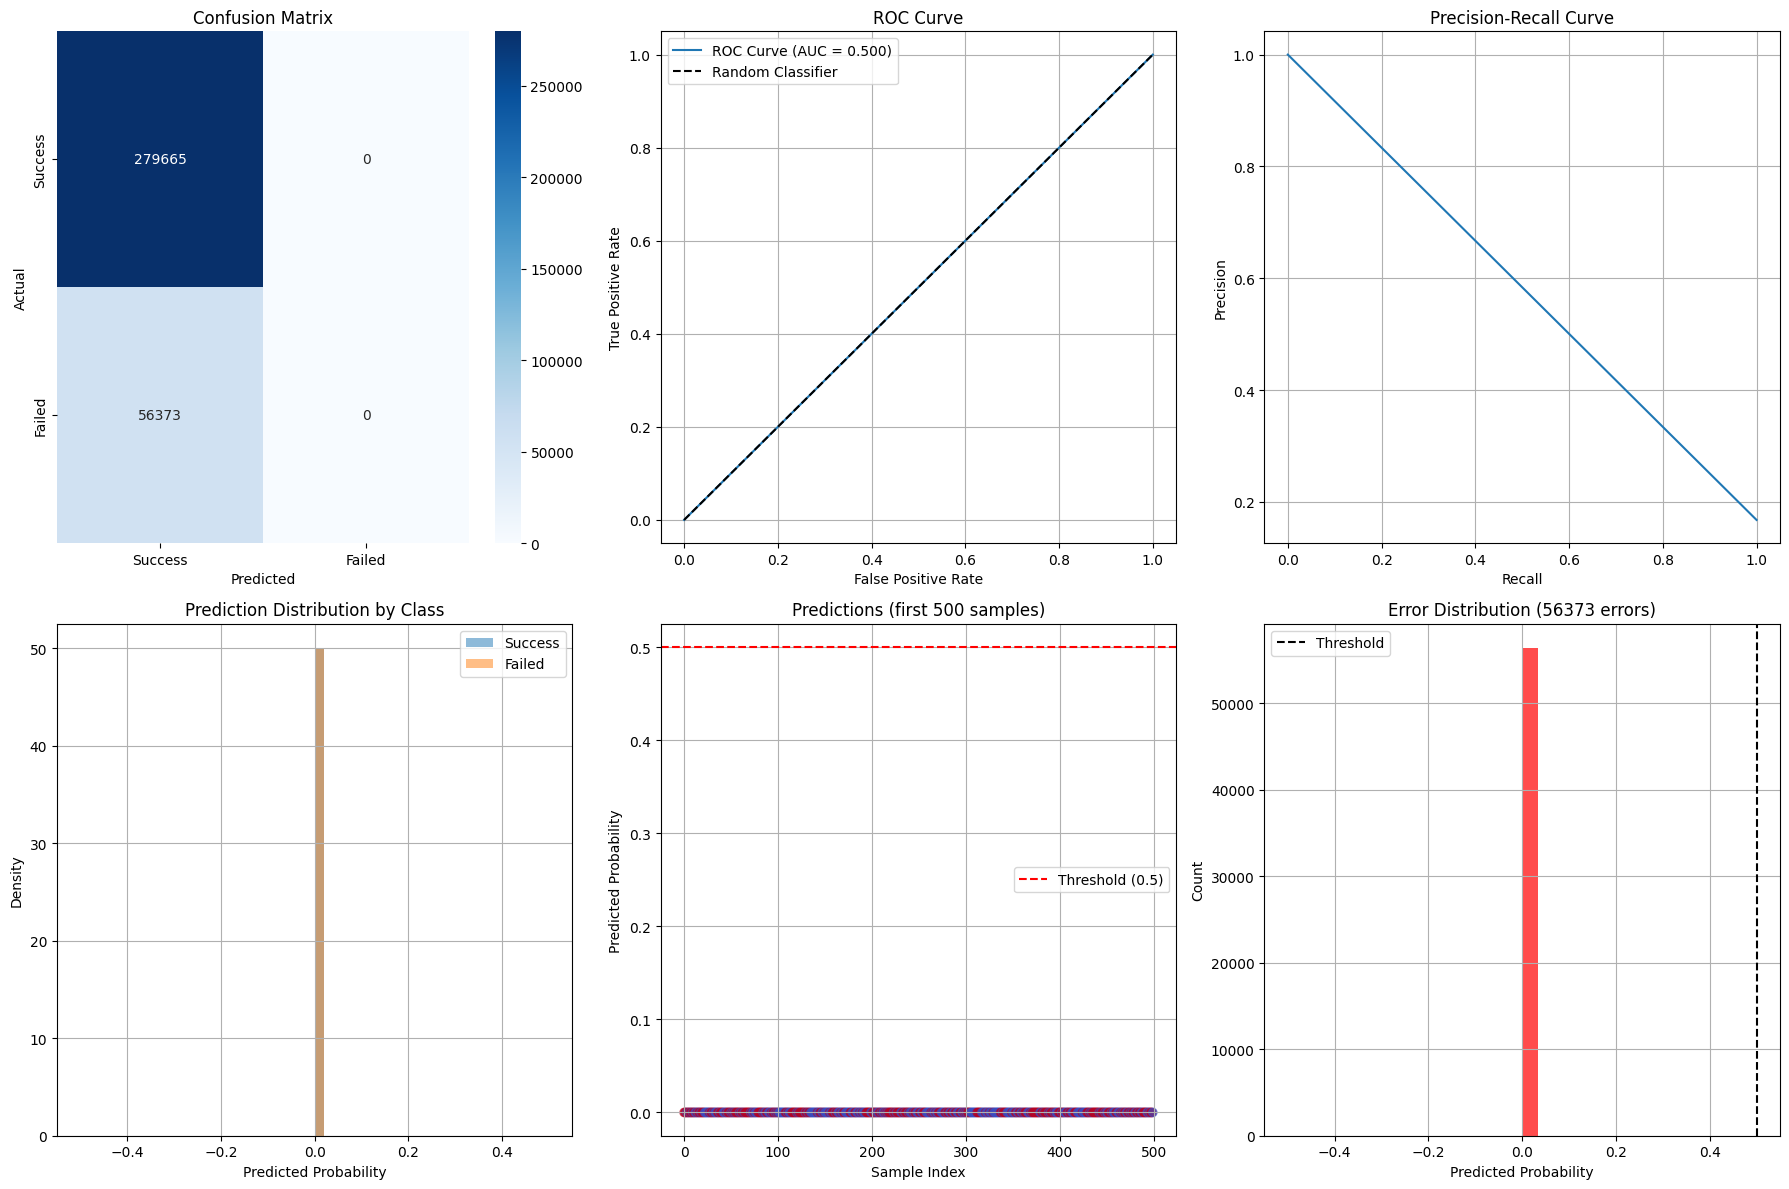


THRESHOLD OPTIMIZATION

Metrics at different thresholds:
    threshold  accuracy  precision  recall   f1
0        0.10    0.8322        0.0     0.0  0.0
1        0.15    0.8322        0.0     0.0  0.0
2        0.20    0.8322        0.0     0.0  0.0
3        0.25    0.8322        0.0     0.0  0.0
4        0.30    0.8322        0.0     0.0  0.0
5        0.35    0.8322        0.0     0.0  0.0
6        0.40    0.8322        0.0     0.0  0.0
7        0.45    0.8322        0.0     0.0  0.0
8        0.50    0.8322        0.0     0.0  0.0
9        0.55    0.8322        0.0     0.0  0.0
10       0.60    0.8322        0.0     0.0  0.0
11       0.65    0.8322        0.0     0.0  0.0
12       0.70    0.8322        0.0     0.0  0.0
13       0.75    0.8322        0.0     0.0  0.0
14       0.80    0.8322        0.0     0.0  0.0
15       0.85    0.8322        0.0     0.0  0.0

✅ Best threshold for F1 score: 0.10 (F1 = 0.0000)

SAMPLE PREDICTIONS

Sample Predictions (first 10 random samples):
--------

/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mudda/mudda_bert/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve
import seaborn as sns

# ============================================
# LOAD THE TRAINED MODEL AND SCALER
# ============================================
print("="*50)
print("LOADING TRAINED MODEL")
print("="*50)

# Load the model
try:
    model = keras.models.load_model('process_failure_predictor_continued.keras')
    print("✅ Model loaded successfully!")
except:
    try:
        model = keras.models.load_model('my_best_model.keras')
        print("✅ Best model loaded successfully!")
    except:
        model = keras.models.load_model('my__best_model.keras')
        print("✅ Original model loaded successfully!")

model.summary()

# Load the scaler
try:
    scaler = joblib.load('scaler.pkl')
    print("✅ Scaler loaded successfully!")
except:
    print("⚠️ Scaler not found. You may need to fit it again.")
    scaler = None

# ============================================
# LOAD TEST DATA
# ============================================
print("\n" + "="*50)
print("LOADING TEST DATA")
print("="*50)

# Load your data
df = pd.read_csv('ready_data.csv')
print(f"✅ Data loaded: {len(df):,} rows, {len(df.columns)} columns")

# Prepare features and target
X = df.drop('failed', axis=1)
y_true = df['failed']

print(f"Features shape: {X.shape}")
print(f"Target distribution:\n{y_true.value_counts()}")

# Identify numerical columns (same as training)
categorical_cols = ['scheduling_class', 'priority', 'collections_events_type', 
                   'vertical_scaling', 'scheduler']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Scale the data if scaler is available
if scaler:
    X_scaled = X.copy()
    X_scaled[numerical_cols] = scaler.transform(X[numerical_cols])
    print("✅ Data scaled successfully!")
else:
    X_scaled = X
    print("⚠️ Using unscaled data!")

# ============================================
# MAKE PREDICTIONS
# ============================================
print("\n" + "="*50)
print("MAKING PREDICTIONS")
print("="*50)

# Get predictions
y_pred_proba = model.predict(X_scaled, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"\nPredictions shape: {y_pred.shape}")
print(f"Predicted failures: {np.sum(y_pred)} ({np.mean(y_pred)*100:.2f}%)")
print(f"Actual failures: {np.sum(y_true)} ({np.mean(y_true)*100:.2f}%)")

# ============================================
# BASIC METRICS
# ============================================
print("\n" + "="*50)
print("BASIC METRICS")
print("="*50)

# Accuracy
accuracy = np.mean(y_pred.flatten() == y_true)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=['Success', 'Failed']))

# ROC-AUC Score
roc_auc = roc_auc_score(y_true, y_pred_proba)
print(f"\nROC-AUC Score: {roc_auc:.4f}")

# ============================================
# VISUALIZATIONS
# ============================================
print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Create a figure with subplots
fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0,0])
axes[0,0].set_title('Confusion Matrix')
axes[0,0].set_xlabel('Predicted')
axes[0,0].set_ylabel('Actual')
axes[0,0].set_xticklabels(['Success', 'Failed'])
axes[0,0].set_yticklabels(['Success', 'Failed'])

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_pred_proba)
axes[0,1].plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.3f})')
axes[0,1].plot([0, 1], [0, 1], 'k--', label='Random Classifier')
axes[0,1].set_xlabel('False Positive Rate')
axes[0,1].set_ylabel('True Positive Rate')
axes[0,1].set_title('ROC Curve')
axes[0,1].legend()
axes[0,1].grid(True)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_true, y_pred_proba)
axes[0,2].plot(recall, precision)
axes[0,2].set_xlabel('Recall')
axes[0,2].set_ylabel('Precision')
axes[0,2].set_title('Precision-Recall Curve')
axes[0,2].grid(True)

# 4. Prediction Distribution
axes[1,0].hist(y_pred_proba[y_true==0], bins=50, alpha=0.5, label='Success', density=True)
axes[1,0].hist(y_pred_proba[y_true==1], bins=50, alpha=0.5, label='Failed', density=True)
axes[1,0].set_xlabel('Predicted Probability')
axes[1,0].set_ylabel('Density')
axes[1,0].set_title('Prediction Distribution by Class')
axes[1,0].legend()
axes[1,0].grid(True)

# 5. Prediction vs Actual
axes[1,1].scatter(range(len(y_pred[:500])), y_pred_proba[:500], c=y_true[:500], cmap='coolwarm', alpha=0.6)
axes[1,1].axhline(y=0.5, color='red', linestyle='--', label='Threshold (0.5)')
axes[1,1].set_xlabel('Sample Index')
axes[1,1].set_ylabel('Predicted Probability')
axes[1,1].set_title('Predictions (first 500 samples)')
axes[1,1].legend()
axes[1,1].grid(True)

# 6. Error Analysis
errors = (y_pred.flatten() != y_true)
axes[1,2].hist(y_pred_proba[errors], bins=30, color='red', alpha=0.7)
axes[1,2].axvline(x=0.5, color='black', linestyle='--', label='Threshold')
axes[1,2].set_xlabel('Predicted Probability')
axes[1,2].set_ylabel('Count')
axes[1,2].set_title(f'Error Distribution ({np.sum(errors)} errors)')
axes[1,2].legend()
axes[1,2].grid(True)

plt.tight_layout()
plt.show()

# ============================================
# THRESHOLD OPTIMIZATION
# ============================================
print("\n" + "="*50)
print("THRESHOLD OPTIMIZATION")
print("="*50)

# Test different thresholds
thresholds = np.arange(0.1, 0.9, 0.05)
results = []

for threshold in thresholds:
    y_pred_threshold = (y_pred_proba > threshold).astype(int)
    accuracy = np.mean(y_pred_threshold.flatten() == y_true)
    precision = np.sum((y_pred_threshold.flatten() == 1) & (y_true == 1)) / max(np.sum(y_pred_threshold.flatten() == 1), 1)
    recall = np.sum((y_pred_threshold.flatten() == 1) & (y_true == 1)) / max(np.sum(y_true == 1), 1)
    f1 = 2 * (precision * recall) / max((precision + recall), 1e-10)
    
    results.append({
        'threshold': threshold,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1
    })

# Convert to DataFrame
threshold_df = pd.DataFrame(results)
print("\nMetrics at different thresholds:")
print(threshold_df.round(4))

# Find best threshold for F1 score
best_threshold = threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold']
best_f1 = threshold_df['f1'].max()
print(f"\n✅ Best threshold for F1 score: {best_threshold:.2f} (F1 = {best_f1:.4f})")

# ============================================
# SAMPLE PREDICTIONS
# ============================================
print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)

# Get 10 random samples
np.random.seed(42)
sample_indices = np.random.choice(len(X), 10, replace=False)

print("\nSample Predictions (first 10 random samples):")
print("-"*80)
print(f"{'Index':<8} {'Actual':<8} {'Predicted':<10} {'Probability':<12} {'Correct?'}")
print("-"*80)

for idx in sample_indices:
    actual = y_true.iloc[idx]
    pred = y_pred[idx][0]
    prob = y_pred_proba[idx][0]
    correct = "✓" if actual == pred else "✗"
    print(f"{idx:<8} {actual:<8} {pred:<10} {prob:.4f}{' ' * 8} {correct}")

# ============================================
# FEATURE IMPORTANCE (if needed)
# ============================================
try:
    from sklearn.inspection import permutation_importance
    
    print("\n" + "="*50)
    print("FEATURE IMPORTANCE")
    print("="*50)
    
    class KerasWrapper:
        def __init__(self, model):
            self.model = model
        def predict(self, X):
            return (self.model.predict(X, verbose=0) > 0.5).astype(int).flatten()
    
    # Use a smaller sample for permutation importance (if dataset is large)
    sample_size = min(1000, len(X_scaled))
    X_sample = X_scaled.sample(n=sample_size, random_state=42)
    y_sample = y_true.loc[X_sample.index]
    
    result = permutation_importance(
        KerasWrapper(model), X_sample, y_sample, 
        n_repeats=5, random_state=42, n_jobs=-1
    )
    
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': result.importances_mean,
        'std': result.importances_std
    }).sort_values('importance', ascending=False)
    
    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10))
    
    # Plot feature importance
    plt.figure(figsize=(10, 6))
    top_features = feature_importance.head(10)
    plt.barh(range(len(top_features)), top_features['importance'], xerr=top_features['std'])
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance')
    plt.title('Top 10 Feature Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
except Exception as e:
    print(f"Could not calculate feature importance: {e}")

# ============================================
# SAVE TEST RESULTS
# ============================================
print("\n" + "="*50)
print("SAVING RESULTS")
print("="*50)

# Save predictions to CSV
results_df = X.copy()
results_df['actual'] = y_true
results_df['predicted_probability'] = y_pred_proba
results_df['predicted_class'] = y_pred
results_df['correct'] = (y_pred.flatten() == y_true)

results_df.to_csv('test_predictions.csv', index=False)
print("✅ Test predictions saved to 'test_predictions.csv'")

# Save metrics summary
with open('test_metrics.txt', 'w') as f:
    f.write("MODEL TEST RESULTS\n")
    f.write("="*50 + "\n")
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"ROC-AUC: {roc_auc:.4f}\n")
    f.write(f"Best Threshold (F1): {best_threshold:.2f}\n")
    f.write(f"Best F1 Score: {best_f1:.4f}\n\n")
    f.write("Confusion Matrix:\n")
    f.write(str(cm) + "\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(y_true, y_pred, target_names=['Success', 'Failed']))

print("✅ Test metrics saved to 'test_metrics.txt'")
print("\n" + "="*50)
print("TESTING COMPLETED")
print("="*50)

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow import keras
import joblib
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# ============================================
# DEBUGGING THE MODEL
# ============================================
print("="*50)
print("DEBUGGING MODEL PREDICTIONS")
print("="*50)

# Load the model
model = keras.models.load_model('my__best_model.keras')
print("✅ Model loaded")

# Load the scaler
scaler = joblib.load('scaler.pkl')
print("✅ Scaler loaded")

# Load data
df = pd.read_csv('ready_data.csv')
print(f"✅ Data loaded: {len(df)} rows")

# Prepare data
X = df.drop('failed', axis=1)
y_true = df['failed']

print("\n" + "="*50)
print("DATA ANALYSIS")
print("="*50)
print(f"Target distribution:\n{y_true.value_counts()}")
print(f"Failed rate: {y_true.mean():.2%}")

# Identify numerical columns
categorical_cols = ['scheduling_class', 'priority', 'collections_events_type', 
                   'vertical_scaling', 'scheduler']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

# Scale the data
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.transform(X[numerical_cols])

# ============================================
# CHECK PREDICTIONS
# ============================================
print("\n" + "="*50)
print("PREDICTION ANALYSIS")
print("="*50)

# Get predictions
y_pred_proba = model.predict(X_scaled, verbose=1)
y_pred = (y_pred_proba > 0.5).astype(int)

print(f"\nPrediction probabilities - Min: {y_pred_proba.min():.4f}, Max: {y_pred_proba.max():.4f}, Mean: {y_pred_proba.mean():.4f}")
print(f"Prediction distribution:")
print(pd.Series(y_pred.flatten()).value_counts())
print(f"\nUnique probability values: {np.unique(y_pred_proba.round(4))}")

# Check if all predictions are the same
if len(np.unique(y_pred)) == 1:
    print("\n❌ PROBLEM: Model is predicting the same class for all samples!")
    print(f"All predictions are: {np.unique(y_pred)[0]}")

# Calculate metrics
accuracy = np.mean(y_pred.flatten() == y_true)
print(f"\nAccuracy: {accuracy:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("\nConfusion Matrix:")
print(cm)

# ROC-AUC (if both classes present in predictions)
try:
    roc_auc = roc_auc_score(y_true, y_pred_proba)
    print(f"ROC-AUC: {roc_auc:.4f}")
except:
    print("ROC-AUC: Could not calculate (only one class predicted)")

# ============================================
# FIX 1: Check model output layer
# ============================================
print("\n" + "="*50)
print("MODEL ARCHITECTURE CHECK")
print("="*50)

# Check last layer activation
last_layer = model.layers[-1]
print(f"Last layer type: {type(last_layer).__name__}")
print(f"Last layer activation: {last_layer.activation.__name__ if hasattr(last_layer, 'activation') else 'No activation'}")
print(f"Last layer output shape: {last_layer.output_shape}")

# ============================================
# FIX 2: Try different thresholds
# ============================================
print("\n" + "="*50)
print("THRESHOLD TESTING")
print("="*50)

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
for threshold in thresholds:
    y_pred_test = (y_pred_proba > threshold).astype(int)
    failed_pred = np.sum(y_pred_test)
    failed_actual = np.sum(y_true)
    accuracy = np.mean(y_pred_test.flatten() == y_true)
    print(f"Threshold {threshold}: Predicted failures: {failed_pred}, Accuracy: {accuracy:.4f}")

# ============================================
# FIX 3: Quick retraining (last few layers only)
# ============================================
print("\n" + "="*50)
print("QUICK FIX: Fine-tune the model")
print("="*50)

# Split data for quick retraining
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true, test_size=0.2, random_state=42, stratify=y_true
)

# Freeze all layers except last few
for layer in model.layers[:-3]:  # Freeze all except last 3 layers
    layer.trainable = False

# Compile with lower learning rate
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Training last layers only...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=20,
    batch_size=32,
    verbose=1,
    class_weight={0: 1, 1: sum(y_train==0)/sum(y_train==1)}  # Handle imbalance
)

# Check predictions after fine-tuning
print("\n" + "="*50)
print("AFTER FINE-TUNING")
print("="*50)

y_pred_proba_new = model.predict(X_scaled, verbose=1)
y_pred_new = (y_pred_proba_new > 0.5).astype(int)

print(f"New prediction probabilities - Min: {y_pred_proba_new.min():.4f}, Max: {y_pred_proba_new.max():.4f}, Mean: {y_pred_proba_new.mean():.4f}")
print(f"New prediction distribution:")
print(pd.Series(y_pred_new.flatten()).value_counts())

# Calculate new metrics
accuracy_new = np.mean(y_pred_new.flatten() == y_true)
print(f"\nNew Accuracy: {accuracy_new:.4f}")

try:
    roc_auc_new = roc_auc_score(y_true, y_pred_proba_new)
    print(f"New ROC-AUC: {roc_auc_new:.4f}")
except:
    print("New ROC-AUC: Could not calculate")

# Save the fixed model
if accuracy_new > accuracy:
    model.save('process_failure_predictor_fixed.keras')
    print("\n✅ Fixed model saved as 'process_failure_predictor_fixed.keras'")
else:
    print("\n⚠️ Fine-tuning didn't improve. Consider retraining from scratch.")

# ============================================
# FIX 4: If still not working, retrain from scratch with correct architecture
# ============================================
print("\n" + "="*50)
print("OPTION: Retrain from scratch with correct architecture")
print("="*50)

def create_correct_model(input_dim):
    model = keras.Sequential([
        keras.layers.Input(shape=(input_dim,)),
        keras.layers.Dense(256, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.3),
        keras.layers.Dense(64, activation='relu'),
        keras.layers.BatchNormalization(),
        keras.layers.Dropout(0.2),
        keras.layers.Dense(32, activation='relu'),
        keras.layers.Dense(1, activation='sigmoid')  # Make sure it's sigmoid!
    ])
    return model

print("\nTo retrain from scratch, run:")
print("""
# Create new model
new_model = create_correct_model(X_scaled.shape[1])
new_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.AUC(name='auc')]
)

# Train
history = new_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=32,
    class_weight={0: 1, 1: sum(y_train==0)/sum(y_train==1)},
    callbacks=[keras.callbacks.EarlyStopping(patience=10)]
)
""")

DEBUGGING MODEL PREDICTIONS
✅ Model loaded


FileNotFoundError: [Errno 2] No such file or directory: 'scaler.pkl'